# Block-1: Environment Setup & Dependencies

In [1]:
# --------- Basic Libraries ---------
import os
import random
import time
import numpy as np
import pandas as pd

In [2]:
# --------- PyTorch Libraries ---------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [3]:
# --------- Torchvision ---------
from torchvision import datasets, transforms, models

In [4]:
# --------- Sklearn ---------
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    accuracy_score
)
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

In [5]:
# --------- Visualization ---------
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# --------- Device Configuration ---------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
# --------- Create Required Directories ---------
os.makedirs("saved_models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

In [8]:
# --------- Set Seed for Reproducibility ---------
def set_seed(seed=16):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(16)

print("Environment setup complete ✅")

Environment setup complete ✅


# Block-2: Fundus Dataset Loading & Preprocessing

In [9]:
# --------- Required Imports (from Block-1 if running notebook) ---------
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
import matplotlib.pyplot as plt

In [10]:
# --------- Dataset Paths (FIXED) ---------
BASE_DIR = "/kaggle/input/datasets/andrewmvd/retinal-disease-classification"

train_dir = os.path.join(BASE_DIR, "Training_Set", "Training_Set")
val_dir   = os.path.join(BASE_DIR, "Evaluation_Set", "Evaluation_Set")
test_dir  = os.path.join(BASE_DIR, "Test_Set", "Test_Set")

In [11]:
# --------- Debug Check ---------
print("Train contents:", os.listdir(train_dir))

Train contents: ['RFMiD_Training_Labels.csv', 'Training']


In [12]:
# --------- Function: Load image paths & labels ---------
def get_image_paths_and_labels(root_dir):
    image_paths = []
    labels = []
    
    class_names = sorted(os.listdir(root_dir))
    class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
    
    for cls in class_names:
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(cls_path, fname))
                labels.append(class_to_idx[cls])
    
    return image_paths, labels, class_to_idx

In [13]:
# --------- Load dataset ---------
train_paths, train_labels, class_to_idx = get_image_paths_and_labels(train_dir)
val_paths, val_labels, _ = get_image_paths_and_labels(val_dir)
test_paths, test_labels, _ = get_image_paths_and_labels(test_dir)
print(f"Train Images: {len(train_paths)}")
print(f"Validation Images: {len(val_paths)}")
print(f"Test Images: {len(test_paths)}")
print(f"Classes: {class_to_idx}")

Train Images: 1920
Validation Images: 640
Test Images: 640
Classes: {'RFMiD_Training_Labels.csv': 0, 'Training': 1}


In [14]:
# --------- Safety Check ---------
if len(train_paths) == 0:
    raise ValueError("❌ No images found! Check dataset structure.")

In [15]:
# --------- Transformations ---------
# SSL Transform (for training)
ssl_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
    transforms.ToTensor()
])

In [16]:
# Evaluation Transform
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [17]:
# --------- Load images ---------
def load_images(image_paths, labels, transform):
    images = []
    new_labels = []
    
    for i in tqdm(range(len(image_paths))):
        try:
            img = Image.open(image_paths[i]).convert("RGB")
            img = transform(img)
            images.append(img.numpy())
            new_labels.append(labels[i])
        except:
            continue
    
    return np.array(images), np.array(new_labels)

In [18]:
# --------- Prepare datasets ---------
train_images, train_labels = load_images(train_paths, train_labels, ssl_transform)
val_images, val_labels     = load_images(val_paths, val_labels, eval_transform)
test_images, test_labels   = load_images(test_paths, test_labels, eval_transform)

print("Train shape:", train_images.shape)
print("Val shape:", val_images.shape)
print("Test shape:", test_images.shape)

100%|██████████| 640/640 [01:53<00:00,  5.65it/s]


Train shape: (1920, 3, 224, 224)
Val shape: (640, 3, 224, 224)
Test shape: (640, 3, 224, 224)


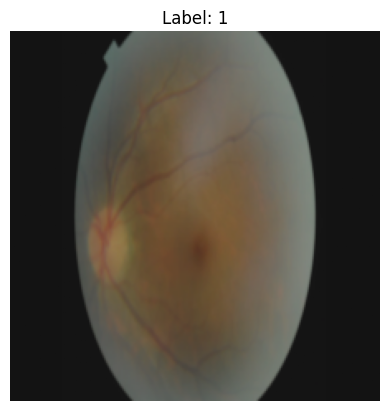

In [19]:
# --------- Visualization (Safe) ---------
if len(train_images) > 0:
    idx = np.random.randint(0, len(train_images))
    plt.imshow(np.transpose(train_images[idx], (1, 2, 0)))
    plt.title(f"Label: {train_labels[idx]}")
    plt.axis('off')
    plt.show()
else:
    print("⚠️ No images to display")

# Block-3: Self-Supervised Model (SimSiam - ResNet18)

In [20]:
# --------- Required Imports---------
import torch
import torch.nn as nn
import torchvision.models as models

In [21]:
# --------- Projection Head ---------
class ProjectionHead(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

In [22]:
# --------- Prediction Head ---------
class PredictionHead(nn.Module):
    def __init__(self, in_dim=128, hidden_dim=64, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

In [23]:
# --------- SimSiam Model ---------
class SimSiam(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder: ResNet18
        self.encoder = models.resnet18(pretrained=True)

        # Remove final classification layer
        self.encoder.fc = nn.Identity()

        # Heads
        self.projector = ProjectionHead(in_dim=512)
        self.predictor = PredictionHead()

    def forward(self, x1, x2):
        # Encode
        z1 = self.encoder(x1)
        z2 = self.encoder(x2)

        # Project
        z1 = self.projector(z1)
        z2 = self.projector(z2)

        # Predict
        p1 = self.predictor(z1)
        p2 = self.predictor(z2)

        return p1, p2, z1.detach(), z2.detach()

In [24]:
# --------- Loss Function (SimSiam) ---------
def negative_cosine_similarity(p, z):
    p = nn.functional.normalize(p, dim=1)
    z = nn.functional.normalize(z, dim=1)
    return - (p * z).sum(dim=1).mean()

def simsiam_loss(p1, p2, z1, z2):
    loss = 0.5 * (
        negative_cosine_similarity(p1, z2) +
        negative_cosine_similarity(p2, z1)
    )
    return loss

In [25]:
# --------- Initialize Model ---------
model = SimSiam().to(device)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s] 


SimSiam(
  (encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

# Block-4: SimSiam Self-Supervised Training

In [26]:
# --------- Required Imports---------
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim

In [27]:
# --------- SSL Dataset (2 Views) ---------
class SimSiamDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        from PIL import Image

        img = Image.open(self.image_paths[idx]).convert("RGB")

        # Two different augmentations
        x1 = self.transform(img)
        x2 = self.transform(img)

        return x1, x2

In [28]:
# --------- Strong Augmentations ---------
ssl_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.ToTensor()
])

In [29]:
# --------- Dataset & Loader ---------
ssl_dataset = SimSiamDataset(train_paths, ssl_transform)

train_loader = DataLoader(
    ssl_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

In [30]:
# --------- Optimizer ---------
optimizer = optim.SGD(model.parameters(), lr=0.03, momentum=0.9, weight_decay=1e-4)

In [31]:
# --------- Training Loop ---------
EPOCHS = 10

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for (x1, x2) in train_loader:
        x1 = x1.to(device)
        x2 = x2.to(device)

        # Forward pass
        p1, p2, z1, z2 = model(x1, x2)

        loss = simsiam_loss(p1, p2, z1, z2)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {avg_loss:.4f}")

# --------- Save Encoder ---------
torch.save(model.encoder.state_dict(), "saved_models/simsiam_encoder.pth")

print("✅ SSL Training Completed & Model Saved")

Epoch [1/10] - Loss: -0.6452
Epoch [2/10] - Loss: -0.9412
Epoch [3/10] - Loss: -0.9474
Epoch [4/10] - Loss: -0.9478
Epoch [5/10] - Loss: -0.9483
Epoch [6/10] - Loss: -0.9487
Epoch [7/10] - Loss: -0.9491
Epoch [8/10] - Loss: -0.9493
Epoch [9/10] - Loss: -0.9491
Epoch [10/10] - Loss: -0.9491
✅ SSL Training Completed & Model Saved


# Block-5: Downstream Classifier Training

In [32]:
# --------- Required Imports---------
import os
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

In [33]:
# --------- SAFE DEVICE SETUP ---------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --------- DATASET PATHS (CORRECT FOR YOUR DATASET) ---------
BASE_DIR = "/kaggle/input/datasets/andrewmvd/retinal-disease-classification"

train_img_dir = os.path.join(BASE_DIR, "Training_Set", "Training_Set", "Training")
train_csv     = os.path.join(BASE_DIR, "Training_Set", "Training_Set", "RFMiD_Training_Labels.csv")

val_img_dir   = os.path.join(BASE_DIR, "Evaluation_Set", "Evaluation_Set", "Validation")
val_csv       = os.path.join(BASE_DIR, "Evaluation_Set", "Evaluation_Set", "RFMiD_Validation_Labels.csv")

Using device: cuda


In [34]:
# --------- LOAD CSV ---------
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)

print("CSV Loaded Successfully")

# --------- SELECT LABEL COLUMN ---------
label_column = train_df.columns[1]
print("Using label column:", label_column)

# --------- CREATE LABEL MAPPING ---------
unique_labels = sorted(train_df[label_column].unique())
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}

num_classes = len(label_to_idx)
print("Number of classes:", num_classes)

CSV Loaded Successfully
Using label column: Disease_Risk
Number of classes: 2


In [35]:
# --------- BUILD DATA ---------
def build_dataset(df, img_dir):
    paths, labels = [], []

    for _, row in df.iterrows():
        img_name = str(row['ID']) + ".png"
        label = row[label_column]

        img_path = os.path.join(img_dir, img_name)

        if os.path.exists(img_path):
            paths.append(img_path)
            labels.append(label_to_idx[label])

    return paths, labels

train_paths, train_labels = build_dataset(train_df, train_img_dir)
val_paths, val_labels     = build_dataset(val_df, val_img_dir)

print("Train Images:", len(train_paths))
print("Validation Images:", len(val_paths))

Train Images: 1920
Validation Images: 640


In [36]:
# --------- SANITY CHECK ---------
print("Sample labels:", train_labels[:10])
print("Max label:", max(train_labels))

Sample labels: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
Max label: 1


In [37]:
# --------- DATASET CLASS ---------
class FundusDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        return img, self.labels[idx]

In [38]:
# --------- TRANSFORM ---------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [39]:
# --------- DATALOADERS ---------
train_loader = DataLoader(FundusDataset(train_paths, train_labels, transform),
                          batch_size=16, shuffle=True)

val_loader = DataLoader(FundusDataset(val_paths, val_labels, transform),
                        batch_size=16, shuffle=False)

# --------- LOAD ENCODER (SAFE) ---------
encoder = models.resnet18(weights=None)
encoder.fc = nn.Identity()

state_dict = torch.load("saved_models/simsiam_encoder.pth", map_location="cpu")
encoder.load_state_dict(state_dict)

# Safe move to GPU
try:
    encoder = encoder.to(device)
    print("Encoder moved to GPU")
except:
    print("GPU issue → using CPU")
    device = torch.device("cpu")
    encoder = encoder.to(device)

Encoder moved to GPU


In [40]:
# --------- FREEZE ENCODER ---------
for p in encoder.parameters():
    p.requires_grad = False

# --------- CLASSIFIER ---------
classifier = nn.Linear(512, num_classes).to(device)

# --------- LOSS & OPTIMIZER ---------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)

In [41]:
# --------- TRAINING LOOP ---------
EPOCHS = 30

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    classifier.train()
    total, correct, loss_sum = 0, 0, 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device).long()

        with torch.no_grad():
            features = encoder(imgs)

        outputs = classifier(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        _, pred = outputs.max(1)

        correct += (pred == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total

    # ---- VALIDATION ----
    classifier.eval()
    v_correct, v_total = 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.to(device).long()

            features = encoder(imgs)
            outputs = classifier(features)
            _, pred = outputs.max(1)
            v_correct += (pred == labels).sum().item()
            v_total += labels.size(0)

    val_acc = 100 * v_correct / v_total

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Loss: {loss_sum/len(train_loader):.4f} | "
          f"Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

Epoch [1/30] | Loss: 0.4367 | Acc: 80.68% | Val Acc: 77.34%
Epoch [2/30] | Loss: 0.3274 | Acc: 86.09% | Val Acc: 79.53%
Epoch [3/30] | Loss: 0.3094 | Acc: 86.09% | Val Acc: 79.06%
Epoch [4/30] | Loss: 0.3156 | Acc: 85.36% | Val Acc: 78.12%
Epoch [5/30] | Loss: 0.3091 | Acc: 86.20% | Val Acc: 79.84%
Epoch [6/30] | Loss: 0.3087 | Acc: 85.47% | Val Acc: 78.91%
Epoch [7/30] | Loss: 0.3017 | Acc: 86.56% | Val Acc: 79.53%
Epoch [8/30] | Loss: 0.3145 | Acc: 86.04% | Val Acc: 79.53%
Epoch [9/30] | Loss: 0.2941 | Acc: 86.82% | Val Acc: 73.91%
Epoch [10/30] | Loss: 0.2871 | Acc: 87.40% | Val Acc: 79.22%
Epoch [11/30] | Loss: 0.2801 | Acc: 87.19% | Val Acc: 79.22%
Epoch [12/30] | Loss: 0.2858 | Acc: 87.24% | Val Acc: 79.22%
Epoch [13/30] | Loss: 0.2741 | Acc: 87.86% | Val Acc: 77.19%
Epoch [14/30] | Loss: 0.2774 | Acc: 86.98% | Val Acc: 78.91%
Epoch [15/30] | Loss: 0.2848 | Acc: 87.08% | Val Acc: 78.44%
Epoch [16/30] | Loss: 0.2832 | Acc: 87.03% | Val Acc: 74.06%
Epoch [17/30] | Loss: 0.2730 | Ac

In [42]:
# --------- SAVE MODEL ---------
torch.save(classifier.state_dict(), "saved_models/classifier.pth")

# Block-6: Evaluation & Visualization

In [43]:
# --------- Required Imports---------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

In [44]:
# --------- Set model to eval ---------
encoder.eval()
classifier.eval()

all_preds = []
all_labels = []
all_probs = []
all_features = []

In [45]:
# --------- Collect Predictions ---------
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        features = encoder(imgs)
        outputs = classifier(features)

        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_features.extend(features.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_features = np.array(all_features)

print("Evaluation data collected")

Evaluation data collected


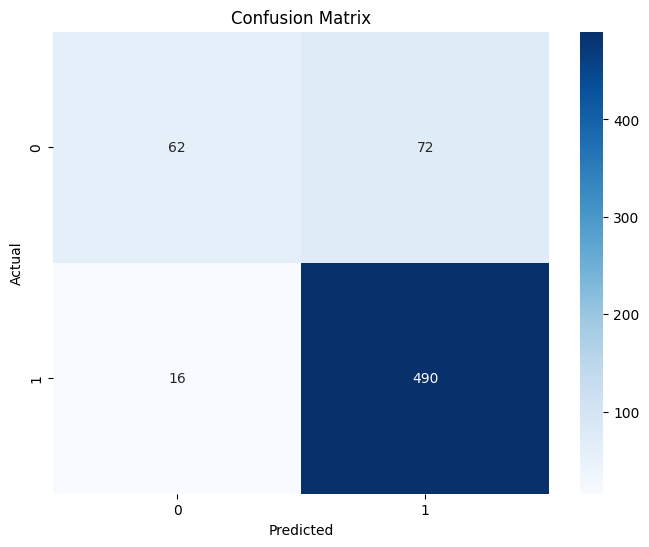

In [46]:
# 🔷 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

In [47]:
# 🔷 2. Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))


Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.46      0.58       134
           1       0.87      0.97      0.92       506

    accuracy                           0.86       640
   macro avg       0.83      0.72      0.75       640
weighted avg       0.86      0.86      0.85       640



Detected classes: 2
Running Binary ROC Curve...


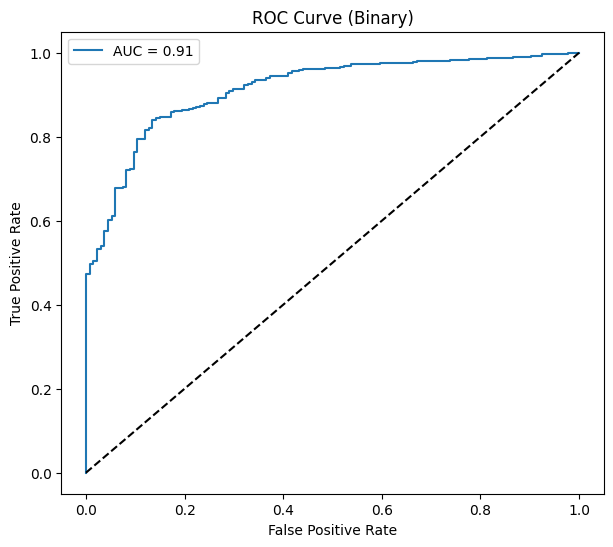

In [48]:
# 🔷 ROC Curve 

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

num_classes = all_probs.shape[1]

print("Detected classes:", num_classes)

# --------- CASE 1: ONLY ONE CLASS ---------
if num_classes == 1:
    print("⚠️ Only ONE class detected → ROC curve not possible.")

# --------- CASE 2: BINARY CLASSIFICATION ---------
elif num_classes == 2:
    print("Running Binary ROC Curve...")

    # Use probability of class 1
    probs = all_probs[:, 1]

    fpr, tpr, _ = roc_curve(all_labels, probs)
    roc_auc = auc(fpr, tpr)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], 'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Binary)")
    plt.legend()

    plt.savefig("roc_curve.png")
    plt.show()

# --------- CASE 3: MULTI-CLASS ---------
else:
    print("Running Multi-class ROC Curve...")

    y_bin = label_binarize(all_labels, classes=list(range(num_classes)))

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,6))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Multi-class)")
    plt.legend()

    plt.savefig("roc_curve.png")
    plt.show()

Running t-SNE...


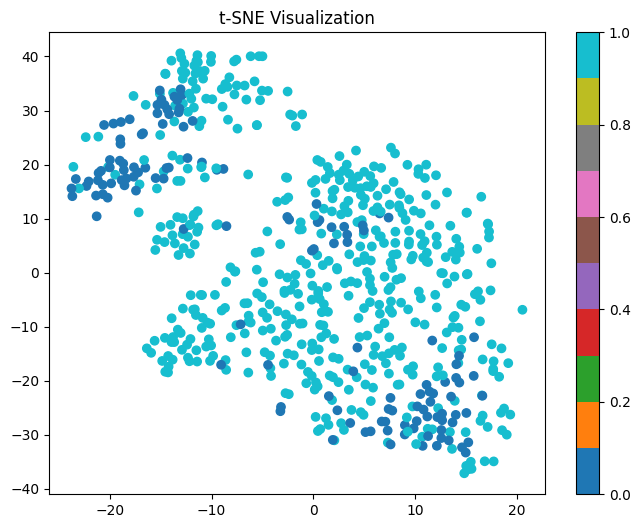

In [49]:
# 🔷 4. t-SNE Visualization
print("Running t-SNE...")

tsne = TSNE(n_components=2, random_state=16)
features_2d = tsne.fit_transform(all_features)

plt.figure(figsize=(8,6))
scatter = plt.scatter(features_2d[:,0], features_2d[:,1], c=all_labels, cmap='tab10')

plt.title("t-SNE Visualization")
plt.colorbar(scatter)
plt.savefig("tsne_plot.png")
plt.show()